# Financial Advisor Summarizer using Agentic AI + Parallelization!

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
#initailize the LLM
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-3.5-turbo')
response = llm.invoke("Hello!")

In [4]:
response.content

'Hello! How can I assist you today?'

In [10]:
from pydantic import BaseModel

class FinanceAdvisorState(BaseModel):
    finance_topic: str = ""
    monthly_earning_summary: str = ""
    financial_goal_summary: str = ""
    risk_assesment_summary: str = ""
    final_advice: str = ""

In [31]:
def monthly_earning_summary(state: FinanceAdvisorState):
    msg = llm.invoke(f"Suggest a best financial advice and strategy with monthly earning of {state.finance_topic}")
    return {"monthly_earning_summary": msg.content}

def create_financial_summary(state: FinanceAdvisorState):
    msg = llm.invoke(f"Suggest the best financial saving advice and strategy with having financial goal of {state.financial_goal_summary}")
    return {"financial_goal_summary": msg.content}

def create_risk_summary(state: FinanceAdvisorState):
    msg = llm.invoke(f"Suggest the best financial advice and strategy , having risk statement as {state.risk_assesment_summary}")
    return {"risk_assesment_summary":msg.content}

def final_advice_summary(state: FinanceAdvisorState):
    prompt = f"""
    You are an expert financial advisor in India. 
    Create a Summarized version of Finance strategy in 500 words for below context:
    Monthly Earning: {state.monthly_earning_summary},
    Finncial Goal: {state.financial_goal_summary},
    Risk Appetite: {state.risk_assesment_summary}
    """
    msg = llm.invoke(prompt)
    return {"final_advice": msg.content}

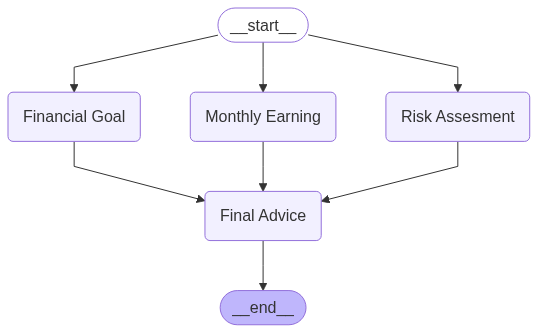

In [32]:
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph = StateGraph(FinanceAdvisorState)

graph.add_node("Monthly Earning", monthly_earning_summary)
graph.add_node("Financial Goal", create_financial_summary)
graph.add_node("Risk Assesment", create_risk_summary)
graph.add_node("Final Advice", final_advice_summary)

graph.add_edge(START, "Monthly Earning")
graph.add_edge(START, "Financial Goal")
graph.add_edge(START, "Risk Assesment")

graph.add_edge("Monthly Earning", "Final Advice")
graph.add_edge("Financial Goal", "Final Advice")
graph.add_edge("Risk Assesment", "Final Advice")

graph.add_edge("Final Advice", END)

graph_compile = graph.compile()
display(Image(graph_compile.get_graph().draw_mermaid_png()))

In [33]:
result = graph_compile.invoke(FinanceAdvisorState(finance_topic="My Monthly earning is 50k, I want to buy a 2bhk apartment and my risk appetite is High"))

In [34]:
result

{'finance_topic': 'My Monthly earning is 50k, I want to buy a 2bhk apartment and my risk appetite is High',
 'monthly_earning_summary': 'Given your monthly earning of 50k and high risk appetite, here is a financial advice and strategy for buying a 2bhk apartment:\n\n1. Start by saving diligently: Allocate a portion of your monthly income towards saving for the down payment of the apartment. Consider setting up a separate savings account or investment portfolio specifically for this goal.\n\n2. Consider investing in high-risk/high-return instruments: Since you have a high risk appetite, you can consider investing in mutual funds, stocks, or real estate investment trusts (REITs) to potentially grow your savings faster. However, make sure to do thorough research and consult with a financial advisor before making any investment decisions.\n\n3. Explore mortgage options: Once you have saved enough for the down payment, consider taking out a mortgage to finance the remaining cost of the apar

In [35]:
print(result['final_advice'])

To achieve your goal of buying a 2bhk apartment with a monthly earning of 50k and a high risk appetite, it is essential to follow a well-thought-out financial strategy:

1. Start by saving diligently towards the down payment, considering a separate savings account or investment portfolio for this purpose.
2. Invest in high-risk/high-return instruments like mutual funds, stocks, or REITs after thorough research and consultation with a financial advisor.
3. Explore mortgage options to finance the remaining cost of the apartment and find the best deal to suit your financial situation.
4. Maintain a diversified portfolio by balancing high-risk investments with low-risk options like fixed deposits or bonds.
5. Regularly review and adjust your financial plan to stay on track towards buying the 2bhk apartment.

Additionally, for a successful financial journey, set a clear financial goal, create a budget, automate savings, cut back on unnecessary expenses, and invest for the long term followin